In [ ]:
from google.colab import files
import pandas as pd
import os

uploaded = files.upload()

print("Uploaded files:")
print(os.listdir())

file_name = [f for f in os.listdir() if f.endswith(".csv")][0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("File:", file_name)
print("Shape:", df.shape)

Saving clusteringmidterm.csv to clusteringmidterm.csv
Uploaded files:
['.config', 'clusteringmidterm.csv', 'sample_data']
Dataset loaded successfully!
File: clusteringmidterm.csv
Shape: (8950, 18)


In [ ]:
print("=== DATASET SHAPE ===")
print(df.shape)

print("\n=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== DATASET INFO ===")
df.info()

print("\n=== MISSING VALUES ===")
print(df.isnull().sum().sort_values(ascending=False))

print("\n=== DUPLICATE ROWS ===")
print(df.duplicated().sum())

print("\n=== BASIC STATISTICS ===")
print(df.describe())

=== DATASET SHAPE ===
(8950, 18)

=== FIRST 5 ROWS ===
  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                   

In [ ]:

if "CUST_ID" in df.columns:
    df = df.drop("CUST_ID", axis=1)

df = df.drop_duplicates()

imputer = SimpleImputer(strategy="median")
df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

print("Shape after cleaning:", df_imputed.shape)

Q1 = df_imputed.quantile(0.25)
Q3 = df_imputed.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clipped = df_imputed.clip(lower=lower, upper=upper, axis=1)

print("Outlier handling completed.")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clipped)

print("Scaling completed.")
print("Final shape:", X_scaled.shape)

Shape after cleaning: (8950, 17)
Outlier handling completed.
Scaling completed.
Final shape: (8950, 17)


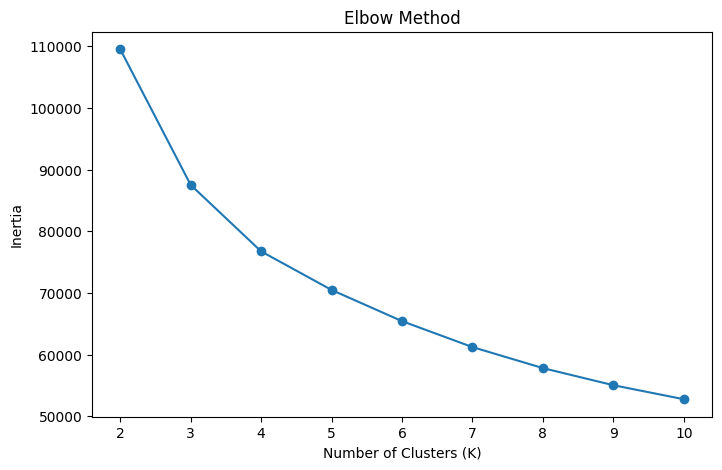

In [ ]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# plot elbow
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

# add labels
df_clipped["KMeans_Cluster"] = kmeans_labels

print(df_clipped["KMeans_Cluster"].value_counts())

KMeans_Cluster
1    3296
3    2154
0    1831
2    1669
Name: count, dtype: int64


In [ ]:
sil_score = silhouette_score(X_scaled, kmeans_labels)
db_score = davies_bouldin_score(X_scaled, kmeans_labels)
ch_score = calinski_harabasz_score(X_scaled, kmeans_labels)

print("=== KMEANS EVALUATION ===")
print("Silhouette Score:", sil_score)
print("Davies-Bouldin Score:", db_score)
print("Calinski-Harabasz Score:", ch_score)

=== KMEANS EVALUATION ===
Silhouette Score: 0.21019325082661994
Davies-Bouldin Score: 1.5153684517527104
Calinski-Harabasz Score: 2582.6391807683895


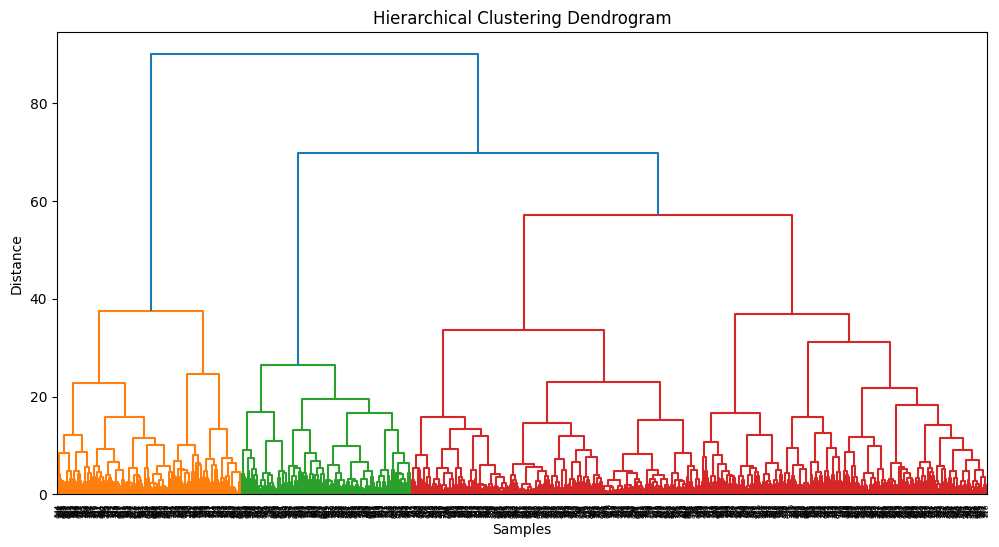

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

sample_data = X_scaled[:1000]

linked = linkage(sample_data, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [ ]:
agg = AgglomerativeClustering(n_clusters=4)

agg_labels = agg.fit_predict(X_scaled)

df_clipped["Agg_Cluster"] = agg_labels

print(df_clipped["Agg_Cluster"].value_counts())

Agg_Cluster
0    3838
3    1990
2    1584
1    1538
Name: count, dtype: int64


In [ ]:
sil_score_agg = silhouette_score(X_scaled, agg_labels)
db_score_agg = davies_bouldin_score(X_scaled, agg_labels)
ch_score_agg = calinski_harabasz_score(X_scaled, agg_labels)

print("=== HIERARCHICAL EVALUATION ===")
print("Silhouette Score:", sil_score_agg)
print("Davies-Bouldin Score:", db_score_agg)
print("Calinski-Harabasz Score:", ch_score_agg)

=== HIERARCHICAL EVALUATION ===
Silhouette Score: 0.17081501986083023
Davies-Bouldin Score: 1.5926339265647487
Calinski-Harabasz Score: 1975.288981055038


In [ ]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df_clipped["DBSCAN_Cluster"] = dbscan_labels

print(df_clipped["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
 0    7024
-1    1926
Name: count, dtype: int64


In [ ]:
if len(set(dbscan_labels)) > 1:
    sil_db = silhouette_score(X_scaled, dbscan_labels)
    db_db = davies_bouldin_score(X_scaled, dbscan_labels)
    ch_db = calinski_harabasz_score(X_scaled, dbscan_labels)

    print("=== DBSCAN EVALUATION ===")
    print("Silhouette Score:", sil_db)
    print("Davies-Bouldin Score:", db_db)
    print("Calinski-Harabasz Score:", ch_db)
else:
    print("DBSCAN produced only one cluster.")

=== DBSCAN EVALUATION ===
Silhouette Score: 0.15637305361384465
Davies-Bouldin Score: 2.751977841466164
Calinski-Harabasz Score: 799.7456050070111


In [ ]:
comparison = pd.DataFrame({
    "Model": ["KMeans", "Hierarchical"],
    "Silhouette": [sil_score, sil_score_agg],
    "Davies-Bouldin": [db_score, db_score_agg],
    "Calinski-Harabasz": [ch_score, ch_score_agg]
})

print(comparison)

          Model  Silhouette  Davies-Bouldin  Calinski-Harabasz
0        KMeans    0.210193        1.515368        2582.639181
1  Hierarchical    0.170815        1.592634        1975.288981


In [ ]:
cluster_profile = df_clipped.groupby("KMeans_Cluster").mean()

print(cluster_profile)

                    BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
KMeans_Cluster                                                                  
0               3089.681753           0.968182   278.203711        161.063946   
1                794.390303           0.887060   260.545168        205.928978   
2               1868.383135           0.979688  2213.207472       1180.717564   
3                488.025130           0.931343   712.857643        105.495696   

                INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
KMeans_Cluster                                                              
0                           100.507529   2135.525350             0.218386   
1                            46.703729    360.491536             0.192903   
2                           684.644357    421.951224             0.898701   
3                           540.623215    100.293992             0.860275   

                ONEOFF_PURCHASES_FREQUENCY  PURCHA